# Análisis del nodo resistente

Métricas de propagación y **resistencia cognitiva** a partir de un run del
`ResistantAgent` (ver `AI_plans/resistencia_cognitiva.md`).

Entradas (carpeta `sim/` de un run):
- `{basename}_agent_states.csv` — estado cognitivo final por agente
  (`theta`, `conviction`, `adopted`, `adopted_at`, `exposures`, `is_seed`).
- `{basename}_adoptions.csv` — eventos de conversión (curva de adopción).
- `{basename}.json` / `.csv` — trazas de mensajes.
- `graph.json` — estructura del grafo.

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# --- Edita estas rutas/parámetros para tu run -----------------------------
RESULTS_DIR_SF = Path("../../data/results/scale_free-resistant")
RESULTS_DIR_SW = Path("../../data/results/watts-resistant")
BASENAME = "simulation"
NARRATIVE_VERACITY_THRESHOLD = 0.30  # debe coincidir con NarrativeConfig
# --------------------------------------------------------------------------

plt.rcParams["figure.dpi"] = 110

## 1. Carga de datos

In [3]:
datasets: dict = {}
for label, rdir in [("scale_free", RESULTS_DIR_SF), ("small_world", RESULTS_DIR_SW)]:
    sdir = rdir / "sim"
    if not sdir.exists():
        print(f"[{label}] directorio no encontrado: {sdir}")
        continue
    st = pd.read_csv(sdir / f"{BASENAME}_agent_states.csv")
    for col in ["adopted", "is_seed"]:
        st[col] = st[col].astype(str).str.lower().map({"true": True, "false": False})
    ad = pd.read_csv(sdir / f"{BASENAME}_adoptions.csv")
    msg_json = sdir / f"{BASENAME}.json"
    msgs = pd.read_json(msg_json) if msg_json.exists() else pd.read_csv(sdir / f"{BASENAME}.csv")
    with open(sdir / "graph.json", encoding="utf-8") as f:
        g = nx.node_link_graph(json.load(f))
    seeds = st.loc[st["is_seed"], "node"].tolist()
    datasets[label] = {
        "states": st, "adoptions": ad, "messages": msgs, "G": g,
        "N": len(st), "seeds": seeds, "n_seeds": len(seeds),
    }
    print(f"[{label}] N={len(st)}  semillas={len(seeds)}  conversiones={len(ad)}  mensajes={len(msgs)}")

[scale_free] N=10000  semillas=1  conversiones=1894  mensajes=137088
[small_world] N=10000  semillas=1  conversiones=21  mensajes=317765


## 2. Métricas poblacionales (titulares)

- **Tasa de ataque** = conversiones / (N − semillas).
- **Resiliencia** = 1 − tasa de ataque.
- **Entropía cognitiva** = H(creyente, no creyente) en bits (colapso → 0).
- **t50** = paso en el que se acumula el 50% de las conversiones.

In [4]:
for label, d in datasets.items():
    st, ad, N, n_seeds = d["states"], d["adoptions"], d["N"], d["n_seeds"]
    n_believers = int(((st["adopted"]) & (~st["is_seed"])).sum())
    denom = N - n_seeds
    attack_rate = n_believers / denom if denom else float("nan")
    p = attack_rate
    entropy = 0.0 if (np.isnan(p) or p in (0.0, 1.0)) else -(p*np.log2(p) + (1-p)*np.log2(1-p))
    if len(ad):
        t_sorted = np.sort(ad["timestep"].to_numpy())
        t50 = int(t_sorted[int(np.ceil(0.5*len(t_sorted))) - 1])
    else:
        t50 = None
    d.update({"n_believers": n_believers, "denom": denom, "attack_rate": attack_rate,
               "resilience": 1 - attack_rate, "entropy": entropy, "t50": t50})

rows = [{
    "run": label,
    "N (no semilla)": d["denom"], "conversiones": d["n_believers"],
    "tasa_ataque": round(d["attack_rate"], 3), "resiliencia": round(d["resilience"], 3),
    "entropía_bits": round(d["entropy"], 3), "t50": d["t50"],
} for label, d in datasets.items()]
pd.DataFrame(rows)

,run,N (no semilla),conversiones,tasa_ataque,resiliencia,entropía_bits,t50
0,scale_free,9999,1894,0.189,0.811,0.700,25
1,small_world,9999,21,0.002,0.998,0.022,30


## 3. Curva de adopción

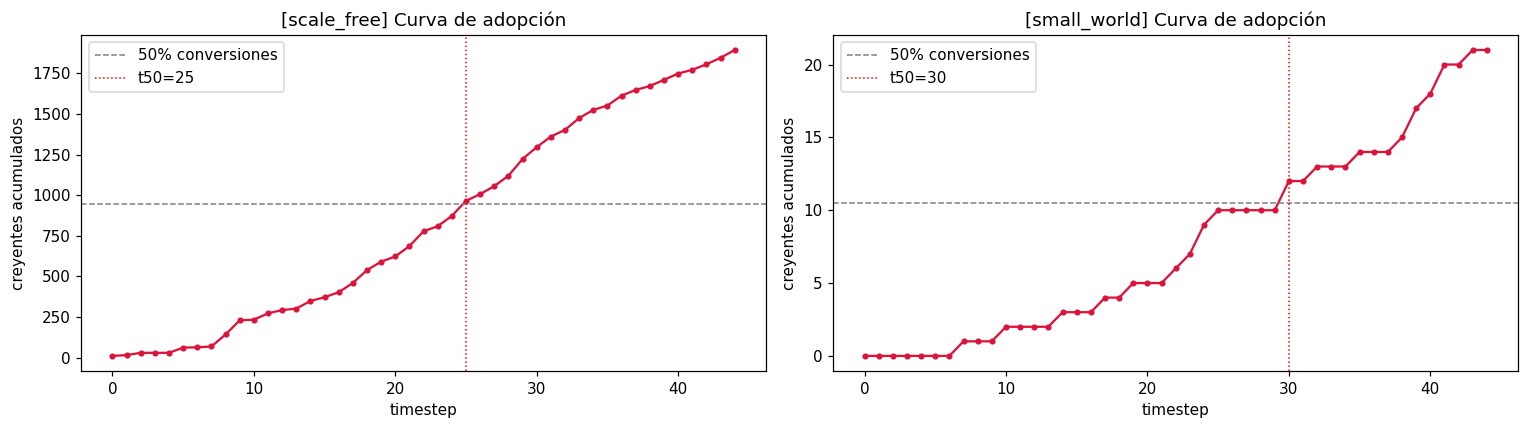

In [5]:
fig, axes = plt.subplots(1, len(datasets), figsize=(7*len(datasets), 4))
axes = np.atleast_1d(axes)
for ax, (label, d) in zip(axes, datasets.items()):
    adoptions, messages, n_believers, t50 = d["adoptions"], d["messages"], d["n_believers"], d["t50"]
    if len(adoptions):
        by_t = adoptions.sort_values("timestep").groupby("timestep").size()
        t_max = int(messages["timestep"].max())
        cum = by_t.cumsum().reindex(range(t_max + 1), method="ffill").fillna(0)
        ax.plot(cum.index, cum.values, marker="o", ms=3, c="crimson")
        ax.axhline(0.5*n_believers, ls="--", c="grey", lw=1, label="50% conversiones")
        if t50 is not None:
            ax.axvline(t50, ls=":", c="red", lw=1, label=f"t50={t50}")
        ax.legend()
    ax.set_xlabel("timestep"); ax.set_ylabel("creyentes acumulados")
    ax.set_title(f"[{label}] Curva de adopción")
plt.tight_layout(); plt.show()

## 4. Dosis–respuesta y umbral de resistencia θ

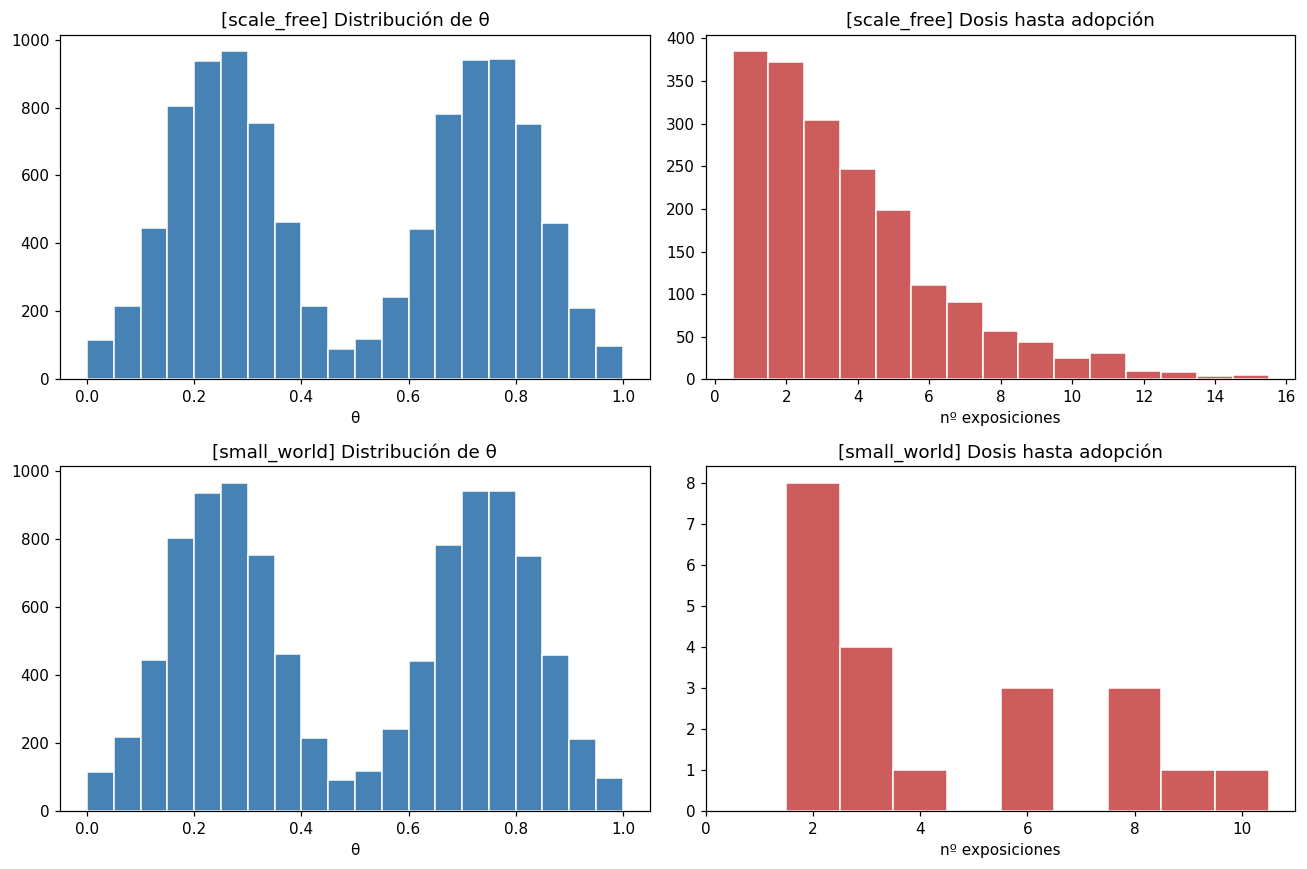

In [6]:
fig, axes = plt.subplots(len(datasets), 2, figsize=(12, 4*len(datasets)))
axes = axes.reshape(len(datasets), 2)
for row, (label, d) in enumerate(datasets.items()):
    states, adoptions = d["states"], d["adoptions"]
    axes[row, 0].hist(states["theta"], bins=20, color="steelblue", edgecolor="white")
    axes[row, 0].set_title(f"[{label}] Distribución de θ"); axes[row, 0].set_xlabel("θ")
    dose = adoptions["exposures"] if len(adoptions) else pd.Series(dtype=int)
    edges = range(1, int(dose.max()) + 2) if len(dose) else [0, 1]
    axes[row, 1].hist(dose, bins=list(edges), color="indianred", edgecolor="white", align="left")
    axes[row, 1].set_title(f"[{label}] Dosis hasta adopción"); axes[row, 1].set_xlabel("nº exposiciones")
plt.tight_layout(); plt.show()

### Curva dosis-respuesta: P(adoptar | θ)

Fracción de no-semillas que adoptan, por banda de resistencia θ. Idealmente
decreciente: a mayor θ, menor probabilidad de caer.

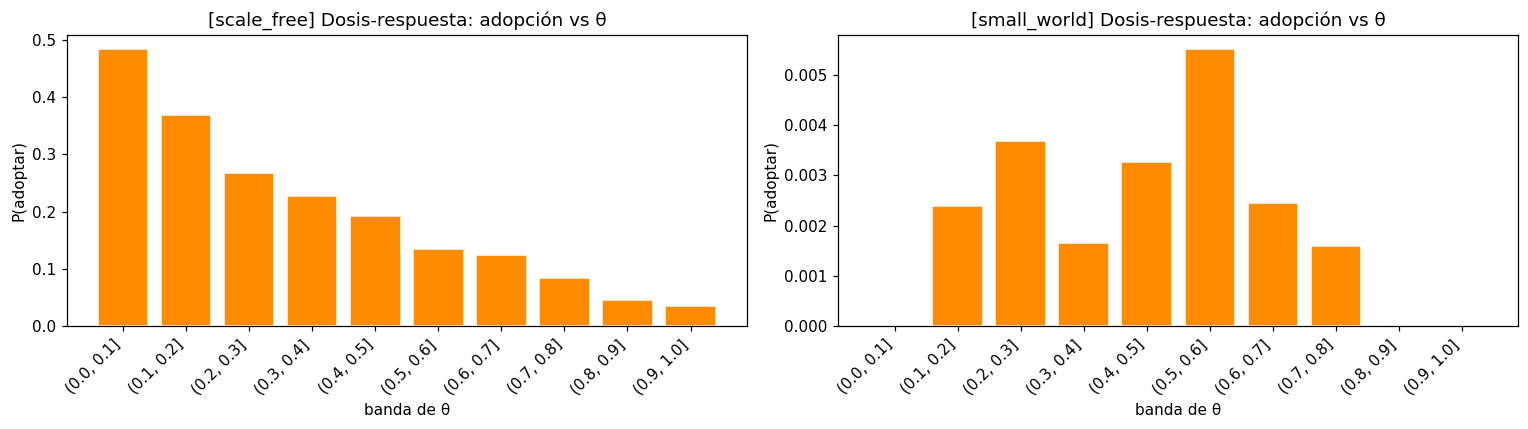

In [7]:
bins = np.linspace(0, 1, 11)
fig, axes = plt.subplots(1, len(datasets), figsize=(7*len(datasets), 4))
axes = np.atleast_1d(axes)
for ax, (label, d) in zip(axes, datasets.items()):
    non_seed = d["states"][~d["states"]["is_seed"]].copy()
    non_seed["theta_bin"] = pd.cut(non_seed["theta"], bins)
    resp = non_seed.groupby("theta_bin", observed=True)["adopted"].mean()
    ax.bar([str(i) for i in resp.index], resp.to_numpy(), color="darkorange", edgecolor="white")
    ax.set_ylabel("P(adoptar)"); ax.set_xlabel("banda de θ")
    ax.set_title(f"[{label}] Dosis-respuesta: adopción vs θ")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout(); plt.show()

## 5. Resistencia individual R_i

Mide cuánta presión confiable aguantó cada nodo **expuesto** a la narrativa:

- No adopta pese a ≥1 exposición: `R_i = 1` (resistente duro).
- Adopta: `R_i = 1 − 1/dosis`, con **dosis = exposiciones en el momento de
  convertir** (de `adoptions.csv`), no el total final tras adoptar (que
  sobreestimaría la resistencia).
- Nunca expuesto: indefinido (se excluye).

[scale_free] Expuestos: 5396 / 9999  R_i media: 0.847
[small_world] Expuestos: 40 / 9999  R_i media: 0.833


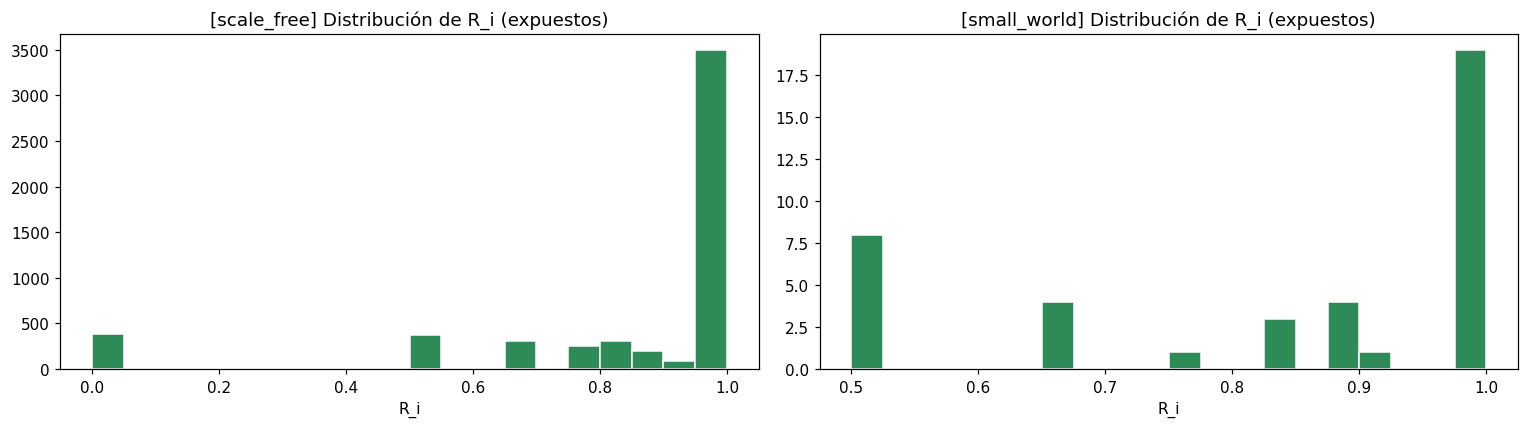

In [8]:
MIN_EXPOSURES = 1

def compute_resistance(d: dict) -> pd.DataFrame:
    states, adoptions = d["states"], d["adoptions"]
    dose_at_adoption = (
        adoptions.set_index("node")["exposures"] if len(adoptions) else pd.Series(dtype=int)
    )
    ns = states[~states["is_seed"]].copy()
    def resistance_row(r):
        if r["adopted"]:
            dose = dose_at_adoption.get(r["node"], r["exposures"])
            return 1 - 1 / max(int(dose), 1)
        return 1.0 if r["exposures"] >= MIN_EXPOSURES else np.nan
    ns["R_i"] = ns.apply(resistance_row, axis=1)
    return ns

fig, axes = plt.subplots(1, len(datasets), figsize=(7*len(datasets), 4))
axes = np.atleast_1d(axes)
for ax, (label, d) in zip(axes, datasets.items()):
    ns = compute_resistance(d)
    exposed = ns.dropna(subset=["R_i"])
    print(f"[{label}] Expuestos: {len(exposed)} / {len(ns)}  R_i media: {exposed['R_i'].mean():.3f}")
    ax.hist(exposed["R_i"], bins=20, color="seagreen", edgecolor="white")
    ax.set_title(f"[{label}] Distribución de R_i (expuestos)")
    ax.set_xlabel("R_i")
plt.tight_layout(); plt.show()

## 6. Propagación de la narrativa (trazas)

[scale_free] Narrativa: 30058 msgs  |  nodos alcanzados: 5419
[small_world] Narrativa: 379 msgs  |  nodos alcanzados: 41


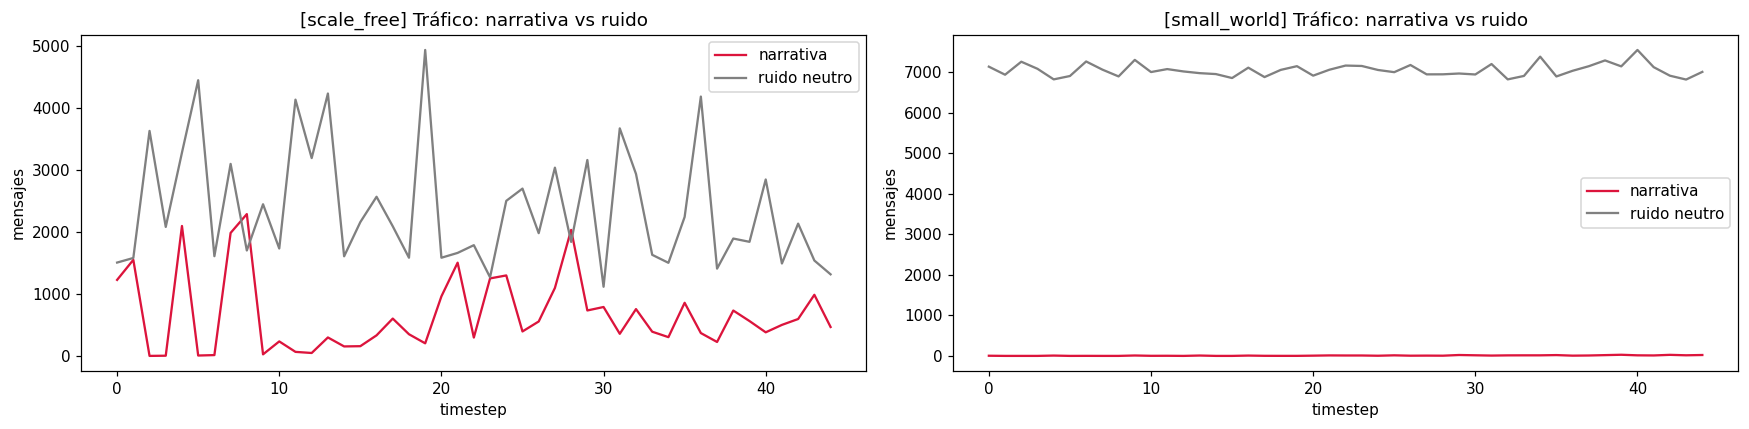

In [9]:
fig, axes = plt.subplots(1, len(datasets), figsize=(8*len(datasets), 4))
axes = np.atleast_1d(axes)
for ax, (label, d) in zip(axes, datasets.items()):
    msgs = d["messages"].copy()
    msgs["is_narrative"] = msgs["veracity"] <= NARRATIVE_VERACITY_THRESHOLD
    per_step = msgs.groupby(["timestep", "is_narrative"]).size().unstack(fill_value=0)
    if True in per_step.columns:
        ax.plot(per_step.index, per_step[True], label="narrativa", c="crimson")
    if False in per_step.columns:
        ax.plot(per_step.index, per_step[False], label="ruido neutro", c="grey")
    ax.set_xlabel("timestep"); ax.set_ylabel("mensajes"); ax.legend()
    ax.set_title(f"[{label}] Tráfico: narrativa vs ruido")
    reach = msgs[msgs["is_narrative"]]["target_node"].nunique()
    print(f"[{label}] Narrativa: {len(msgs[msgs['is_narrative']])} msgs  |  nodos alcanzados: {reach}")
plt.tight_layout(); plt.show()

## 7. Comparación hubs vs aleatoria

Lanza **dos runs** con la misma topología y `seed_strategy` distinta
(`hubs` y `random`), guárdalos en carpetas separadas y compara su tasa de
ataque. La diferencia mide la **vulnerabilidad estructural** de la red.

In [10]:
def population_metrics(results_dir: Path, basename: str = "simulation") -> dict:
    sdir = results_dir / "sim"
    st = pd.read_csv(sdir / f"{basename}_agent_states.csv")
    for c in ["adopted", "is_seed"]:
        st[c] = st[c].astype(str).str.lower().map({"true": True, "false": False})
    n = len(st); nseed = int(st["is_seed"].sum())
    bel = int(((st["adopted"]) & (~st["is_seed"])).sum())
    ar = bel / (n - nseed) if (n - nseed) else float("nan")
    return {"run": results_dir.name, "N": n, "semillas": nseed,
            "conversiones": bel, "tasa_ataque": round(ar, 3),
            "resiliencia": round(1 - ar, 3)}

# Edita a tus runs de comparación (hubs vs random):
comparison_dirs = [
    Path("../../data/results/scale_free-resistant"),
    Path("../../data/results/watts-resistant"),
]
rows = [population_metrics(d) for d in comparison_dirs if (d / "sim").exists()]
pd.DataFrame(rows)

,run,N,semillas,conversiones,tasa_ataque,resiliencia
0,scale_free-resistant,10000,1,1894,0.189,0.811
1,watts-resistant,10000,1,21,0.002,0.998
